# Projeto Integrador

## Imports e Análises Iniciais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

In [14]:
df = pd.read_csv("dados/dataset.csv")
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [15]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [16]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [18]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [19]:
df = df.drop(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'key', 'mode','explicit'], axis=1)

In [20]:
df.columns #quis remover o boleano pq fiquei com medo de interferir muito na análise, mas se for necessário posso colocar ele de volta

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

| Coluna | Descrição | Tipo |
| --- | --- | --- |
| key | tonalidade da música (0–11, representando C, C#, D, ... B em notação cromática) | Numérica discreta |
| mode | maior (1) ou menor (0) — a escala da música | Binária |
| valence | medida de positividade/felicidade (0–1). Quanto maior, mais alegre/positiva a música | Contínua |
| tempo | velocidade em BPM (batidas por minuto). Ex: 120 BPM = andamento moderado | Contínua |
| time_signature | compasso/assinatura de tempo (ex: 4/4, 3/4) | Discreta; geralmente 4 é mais comum em pop/rock |

ao meu ver, vale a pena deixar o valence, tempo e time signature talvez

In [21]:
df.dtypes

popularity            int64
duration_ms           int64
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object

In [22]:
print("NaNs por coluna:\n", df.isnull().sum())

NaNs por coluna:
 popularity          0
duration_ms         0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
dtype: int64


<Axes: xlabel='popularity', ylabel='Count'>

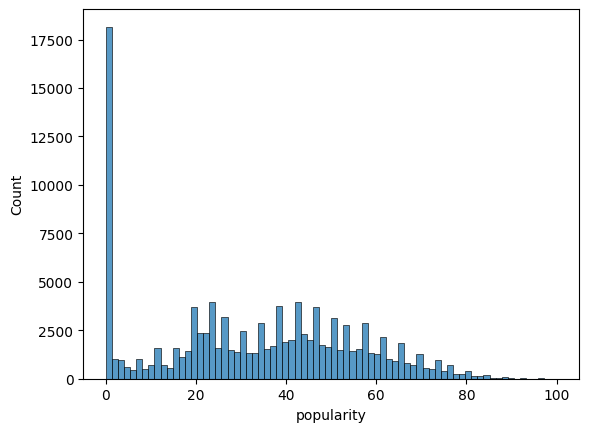

In [25]:
sns.histplot(df['popularity'])

<Axes: xlabel='duration_ms', ylabel='Count'>

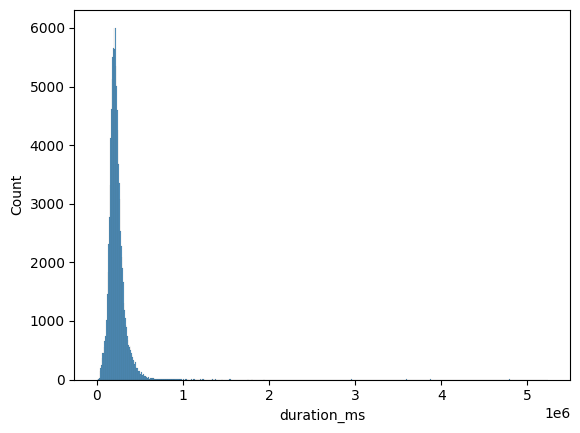

In [26]:
sns.histplot(df['duration_ms'])

<Axes: xlabel='danceability', ylabel='Count'>

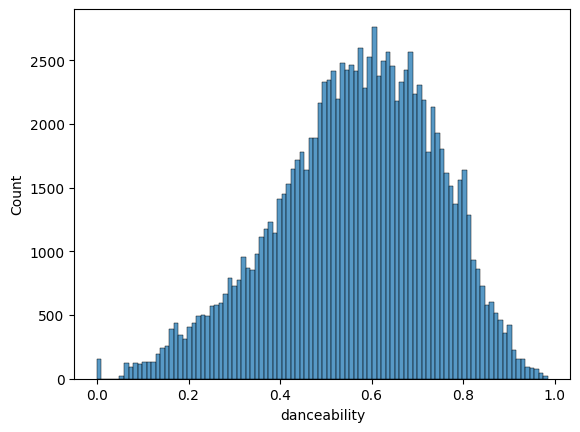

In [27]:
sns.histplot(df['danceability'])

<Axes: xlabel='acousticness', ylabel='Count'>

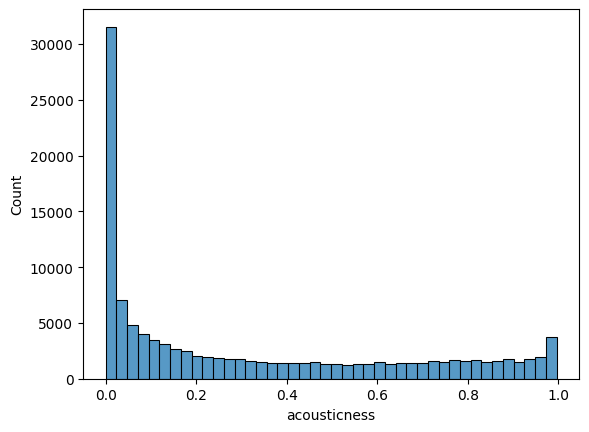

In [28]:
sns.histplot(df['acousticness'])

## PCA

In [9]:
spark = SparkSession.builder.appName("PCA").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/25 08:15:48 WARN Utils: Your hostname, lucas-dell, resolves to a loopback address: 127.0.1.1; using 172.16.242.227 instead (on interface wlp3s0)
26/05/25 08:15:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 08:15:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [10]:
spark_df = spark.createDataFrame(df)

In [11]:
assembler = VectorAssembler(inputCols=spark_df.columns, outputCol="features")
vetor = assembler.transform(spark_df)

In [12]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True,withStd=True)
scaler_model = scaler.fit(vetor)
df_scaled = scaler_model.transform(vetor)

26/05/25 08:16:50 WARN TaskSetManager: Stage 0 contains a task of very large size (1311 KiB). The maximum recommended task size is 1000 KiB.


In [13]:
df_scaled.toPandas()

26/05/25 08:17:03 WARN TaskSetManager: Stage 3 contains a task of very large size (1311 KiB). The maximum recommended task size is 1000 KiB.


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,features,scaled_features
0,73,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,"[73.0, 230666.0, 0.676, 0.461, -6.746, 0.143, ...","[1.7826193673380515, 0.024575052169950158, 0.6..."
1,55,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,"[55.0, 149610.0, 0.42, 0.166, -17.235, 0.0763,...","[0.9756282596695175, -0.7308557767074891, -0.8..."
2,57,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,"[57.0, 210826.0, 0.438, 0.359, -9.734, 0.0557,...","[1.0652939382993545, -0.1603310330665332, -0.7..."
3,71,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,"[71.0, 201933.0, 0.266, 0.0596, -18.515, 0.036...","[1.6929536887082144, -0.24321257621210007, -1...."
4,82,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,"[82.0, 198853.0, 0.618, 0.443, -9.681, 0.0526,...","[2.1861149211723188, -0.27191775476695734, 0.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0.172,0.2350,-16.393,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,"[21.0, 384999.0, 0.172, 0.235, -16.393, 0.0422...","[-0.5486882770377137, 1.4629374943474798, -2.2..."
113996,22,385000,0.174,0.1170,-18.318,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,"[22.0, 385000.0, 0.174, 0.117, -18.318, 0.0401...","[-0.5038554377227952, 1.462946814210647, -2.26..."
113997,22,271466,0.629,0.3290,-10.895,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,"[22.0, 271466.0, 0.629, 0.329, -10.895, 0.042,...","[-0.5038554377227952, 0.40482546939013775, 0.3..."
113998,41,283893,0.587,0.5060,-10.889,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,"[41.0, 283893.0, 0.587, 0.506, -10.889, 0.0297...","[0.3479685092606576, 0.5206434089684532, 0.116..."


## Modelo de Agrupamento